# Toss/Turn & Scratch — Group Comparison Analysis

Compares toss/turn and scratch activity across AD severity groups (Severe / Moderate / Control) for participants with a validated PSG-EMFIT sync (`sync_status == 'OK'`).

**Analyses:**
1. Distribution of raw toss/turn and scratch counts by group
2. Distribution of toss/turn and scratch rate **per hour of true sleep** by group
3. True sleep duration by group
4. Correlations between EASI score, sleep duration, scratch rate, and toss/turn rate

**Note on sleep duration:** computed as total time scored as any stage other than `Wake` in the `Sleep.stage` column (REM/NREM not distinguished) — not the raw PSG recording window, which would include time-in-bed before/after sleep onset.

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, spearmanr
from pathlib import Path
import re
import itertools

sns.set_style('whitegrid')

# Okabe-Ito colourblind-safe palette, fixed per group across every plot in this notebook
GROUP_PALETTE = {
    'Group 1': '#E69F00',  # orange
    'Group 2': '#56B4E9',  # sky blue
    'Group 3': '#009E73',  # bluish green
}
GROUP_ORDER = ['Group 1', 'Group 2', 'Group 3']

## 1. Load data and prepare groups

In [90]:
participant_data_path = Path("C:/Users/ryadl/Desktop/EMFIT_local/Emfit_1/logs/emfit_participant_data.csv")
processed_dir = Path("C:/Users/ryadl/Desktop/EMFIT_local/Emfit_1/data/processed")

df = pd.read_csv(participant_data_path)
df = df[df['sync_status'] == 'OK'].copy()

GROUP_LABELS = {1: 'Group 1', 2: 'Group 2', 3: 'Group 3'}
df['group'] = pd.to_numeric(df['group'], errors='coerce')
df['group_label'] = df['group'].map(GROUP_LABELS)
df['easi'] = pd.to_numeric(df['easi'], errors='coerce')

print(f"Participants with OK sync status: {len(df)}")
print(df['group_label'].value_counts(dropna=False))

Participants with OK sync status: 27
group_label
Group 2    12
Group 3     9
Group 1     6
Name: count, dtype: int64


## 2. Compute true sleep duration (excludes Wake epochs)

In [91]:
def resolve_processed_path(row_id, processed_dir):
    """Locate the Visit_X folder in data/processed for a given row_id (e.g. 'MS8', 'MS53V1')."""
    match = re.match(r'(MS\d+)(V(\d+))?$', row_id)
    if not match:
        return None
    base_id = match.group(1)
    visit_num = match.group(3)
    participant_path = processed_dir / base_id
    if not participant_path.exists():
        return None
    if visit_num:
        visit_dir = participant_path / f"Visit_{visit_num}"
        return visit_dir if visit_dir.exists() else None
    visit_dirs = sorted(participant_path.glob("Visit_*"))
    if len(visit_dirs) != 1:
        return None
    return visit_dirs[0]


def compute_true_sleep_hours(row_id, processed_dir):
    """
    True sleep time = total seconds where Sleep.stage is scored and is not 'Wake'.
    Returns (sleep_hours, unique_stage_values) or (None, None) if unavailable.
    """
    visit_dir = resolve_processed_path(row_id, processed_dir)
    if visit_dir is None:
        return None, None

    tt_files = list(visit_dir.glob("*_acti_psg_SSandArousal_1s_tt.csv"))
    if not tt_files:
        return None, None

    tt_df = pd.read_csv(tt_files[0])
    if 'Sleep.stage' not in tt_df.columns:
        return None, None

    stages = tt_df['Sleep.stage'].dropna().str.strip()
    unique_stages = stages.str.lower().unique().tolist()

    sleep_seconds = (stages.str.lower() != 'wake').sum()
    return sleep_seconds / 3600, unique_stages


true_sleep_hours_list = []
all_unique_stages = set()
failed_sleep_calc = []

for _, row in df.iterrows():
    hours, stages = compute_true_sleep_hours(row['participant_id'], processed_dir)
    true_sleep_hours_list.append(hours)
    if stages:
        all_unique_stages.update(stages)
    if hours is None:
        failed_sleep_calc.append(row['participant_id'])

df['true_sleep_hours'] = true_sleep_hours_list

print(f"Unique Sleep.stage values found across dataset: {sorted(all_unique_stages)}")
if failed_sleep_calc:
    print(f"\nCould not compute true sleep duration for: {failed_sleep_calc}")
else:
    print("\nTrue sleep duration computed for all participants.")

Unique Sleep.stage values found across dataset: ['n1', 'n2', 'n3', 'rem', 'wake']

True sleep duration computed for all participants.


## 3. Recompute toss/turn & scratch rates per hour of TRUE sleep


In [92]:
# Recompute toss/turn and scratch rates using TRUE SLEEP TIME as the denominator
# (events per hour of actual sleep, rather than per hour of PSG recording/time-in-bed)
df['toss_turn_per_hour_sleep'] = df.apply(
    lambda r: r['toss_turn_count'] / r['true_sleep_hours']
    if pd.notna(r['true_sleep_hours']) and r['true_sleep_hours'] > 0 else np.nan,
    axis=1
)
df['scratch_per_hour_sleep'] = df.apply(
    lambda r: r['scratch_count'] / r['true_sleep_hours']
    if pd.notna(r['true_sleep_hours']) and r['true_sleep_hours'] > 0 else np.nan,
    axis=1
)

n_zero_tt = (df['toss_turn_count'] == 0).sum()
n_missing_tt = df['toss_turn_count'].isna().sum()
n_zero_scratch = (df['scratch_count'] == 0).sum()
n_missing_scratch = df['scratch_count'].isna().sum()

print(f"Toss/turn — zero events: {n_zero_tt}, missing: {n_missing_tt}")
print(f"Scratch   — zero events: {n_zero_scratch}, missing: {n_missing_scratch}")
print("\nNote: zero is treated as a genuine data point (no events detected) and kept in all analyses.")
print("Missing (NaN) values are excluded pairwise by the plotting/test functions below.")

Toss/turn — zero events: 2, missing: 0
Scratch   — zero events: 2, missing: 0

Note: zero is treated as a genuine data point (no events detected) and kept in all analyses.
Missing (NaN) values are excluded pairwise by the plotting/test functions below.


## Helper functions for plotting & testing

In [133]:
def group_boxplot(data, value_col, title, ax, order=GROUP_ORDER, palette=GROUP_PALETTE):
    """Boxplot + stripplot for one variable across groups, with Kruskal-Wallis result
    in the subtitle and per-group n/median annotated directly on the plot."""
    sns.boxplot(data=data, x='group_label', y=value_col, order=order, hue='group_label',
                palette=palette, legend=False, ax=ax, showfliers=False)
    sns.stripplot(data=data, x='group_label', y=value_col, order=order, ax=ax,
                  color='black', alpha=0.6, jitter=True, size=4)

    groups = [data[data['group_label'] == g][value_col].dropna().values for g in order]
    groups_nonempty = [g for g in groups if len(g) > 0]

    if len(groups_nonempty) >= 2:
        stat, p = kruskal(*groups_nonempty)
        p_str = f"p = {p:.4f}" if p >= 0.0001 else "p < 0.0001"
        subtitle = f"Kruskal-Wallis: H = {stat:.2f}, {p_str}"
    else:
        stat, p = None, None
        subtitle = "Kruskal-Wallis: insufficient data"

    stats_lines = []
    for g, vals in zip(order, groups):
        if len(vals) > 0:
            stats_lines.append(f"{g}: n={len(vals)}, median={np.median(vals):.2f}")
        else:
            stats_lines.append(f"{g}: n=0")
    stats_text = "\n".join(stats_lines)

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, va='top', ha='left',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

    ax.set_title(f"{title}\n{subtitle}", fontsize=11)
    ax.set_xlabel('')
    return stat, p


def zoom_axis(ax, values, axis='x', k=2.5, clip=True):
    """Adjust the visible axis range. If clip=True (default), clips to ~k*IQR beyond Q3
    and flags outliers left outside the frame. If clip=False, extends the range to
    include ALL points (with a small margin) so nothing falls off-axis."""
    values = pd.Series(values).dropna()
    if len(values) < 4:
        return
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr <= 0:
        return
    upper = q3 + k * iqr
    n_outliers = (values > upper).sum()

    if not clip:
        # Include every point, with a 5% margin on each side
        span = values.max() - values.min()
        margin = max(span * 0.05, 1e-6)
        lo = max(values.min() - margin, 0)
        hi = values.max() + margin
        if axis == 'x':
            ax.set_xlim(left=lo, right=hi)
        else:
            ax.set_ylim(bottom=lo, top=hi)
        return

    if n_outliers == 0:
        return
    margin = max((upper - values.min()) * 0.05, 1e-6)
    note = f"{n_outliers} point(s) beyond axis (max={values.max():.0f})"
    if axis == 'x':
        ax.set_xlim(left=max(values.min() - margin, 0), right=upper)
        ax.annotate(note, xy=(0.99, 0.93), xycoords='axes fraction', ha='right', va='top',
                    fontsize=7.5, color='dimgray', style='italic')
    else:
        ax.set_ylim(bottom=max(values.min() - margin, 0), top=upper)
        ax.annotate(note, xy=(0.99, 0.98), xycoords='axes fraction', ha='right', va='top',
                    fontsize=7.5, color='dimgray', style='italic')


def scatter_with_group_regression(data, x, y, title, ax, order=GROUP_ORDER, palette=GROUP_PALETTE,
                                   group_col='group_label', show_line=True):
    """Scatter plot with Spearman rho and p-value PER GROUP. Regression line drawn only
    if show_line=True — set False when the line would visually overstate a weak/non-
    significant correlation."""
    sns.scatterplot(data=data, x=x, y=y, hue=group_col, hue_order=order, palette=palette,
                     ax=ax, alpha=0.85, s=60, edgecolor='black', linewidth=0.4)

    stats_lines = []
    for g in order:
        sub = data[data[group_col] == g][[x, y]].dropna()
        color = palette[g]
        if len(sub) >= 3 and sub[x].nunique() > 1 and sub[y].nunique() > 1:
            rho, p = spearmanr(sub[x], sub[y])
            if show_line:
                sns.regplot(data=sub, x=x, y=y, ax=ax, scatter=False, color=color, ci=None,
                            line_kws={'linestyle': '--', 'alpha': 0.85, 'linewidth': 2})
            p_str = f"p={p:.3f}" if p >= 0.001 else "p<0.001"
            stats_lines.append(f"{g}: rho={rho:.2f}, {p_str}, n={len(sub)}")
        else:
            stats_lines.append(f"{g}: insufficient data (n={len(sub)})")

    stats_text = "\n".join(stats_lines)
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, va='top', ha='left',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.88, edgecolor='gray'))

    zoom_axis(ax, data[x], axis='x')

    ax.set_title(title, fontsize=11)
    ax.legend(loc='lower right', fontsize=8, framealpha=0.9)


def pooled_and_per_group_scatter(data, x, y, suptitle, axes, order=GROUP_ORDER, palette=GROUP_PALETTE):
    """Lays out one pooled panel (all groups overlaid, one overall regression line)
    followed by one panel per group (each with its own scale and its own regression
    line), so groups never compete for the same axis range or overlapping lines.
    `axes` must have length len(order) + 1 — axes[0] is the pooled panel."""

    # --- Pooled panel ---
    ax_pooled = axes[0]
    sns.scatterplot(data=data, x=x, y=y, hue='group_label', hue_order=order, palette=palette,
                     ax=ax_pooled, alpha=0.85, s=55, edgecolor='black', linewidth=0.4)

    sub_all = data[[x, y]].dropna()
    if len(sub_all) >= 3 and sub_all[x].nunique() > 1 and sub_all[y].nunique() > 1:
        rho, p = spearmanr(sub_all[x], sub_all[y])
        sns.regplot(data=sub_all, x=x, y=y, ax=ax_pooled, scatter=False, color='black', ci=None,
                    line_kws={'linestyle': '--', 'alpha': 0.8, 'linewidth': 2})
        p_str = f"p={p:.3f}" if p >= 0.001 else "p<0.001"
        stat_text = f"Pooled: rho={rho:.2f}, {p_str}, n={len(sub_all)}"
    else:
        stat_text = f"Pooled: insufficient data (n={len(sub_all)})"

    ax_pooled.text(0.02, 0.98, stat_text, transform=ax_pooled.transAxes, va='top', ha='left',
                   fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.88, edgecolor='gray'))
    zoom_axis(ax_pooled, data[x], axis='x', clip = False)
    ax_pooled.set_title('Pooled (all groups)', fontsize=10)
    ax_pooled.legend(loc='lower right', fontsize=7, framealpha=0.9)

    # --- One panel per group ---
    for ax, g in zip(axes[1:], order):
        sub = data[data['group_label'] == g][[x, y]].dropna()
        color = palette[g]
        sns.scatterplot(data=sub, x=x, y=y, ax=ax, color=color, alpha=0.85, s=55,
                         edgecolor='black', linewidth=0.4)

        if len(sub) >= 3 and sub[x].nunique() > 1 and sub[y].nunique() > 1:
            rho, p = spearmanr(sub[x], sub[y])
            sns.regplot(data=sub, x=x, y=y, ax=ax, scatter=False, color=color, ci=None,
                        line_kws={'linestyle': '--', 'alpha': 0.85, 'linewidth': 2})
            p_str = f"p={p:.3f}" if p >= 0.001 else "p<0.001"
            stat_text = f"rho={rho:.2f}, {p_str}, n={len(sub)}"
        else:
            stat_text = f"insufficient data (n={len(sub)})"

        ax.text(0.02, 0.98, stat_text, transform=ax.transAxes, va='top', ha='left',
                fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.88, edgecolor='gray'))
        zoom_axis(ax, sub[x], axis='x', clip=False)
        ax.set_title(g, fontsize=10)

    axes[0].figure.text(0.5, 1.02, suptitle, ha='center', fontsize=13, fontweight='bold',
                         transform=axes[0].figure.transFigure)

# Sleep stage analysis across groups.

## Analysis 1 — Toss/turn count and scratch count by group

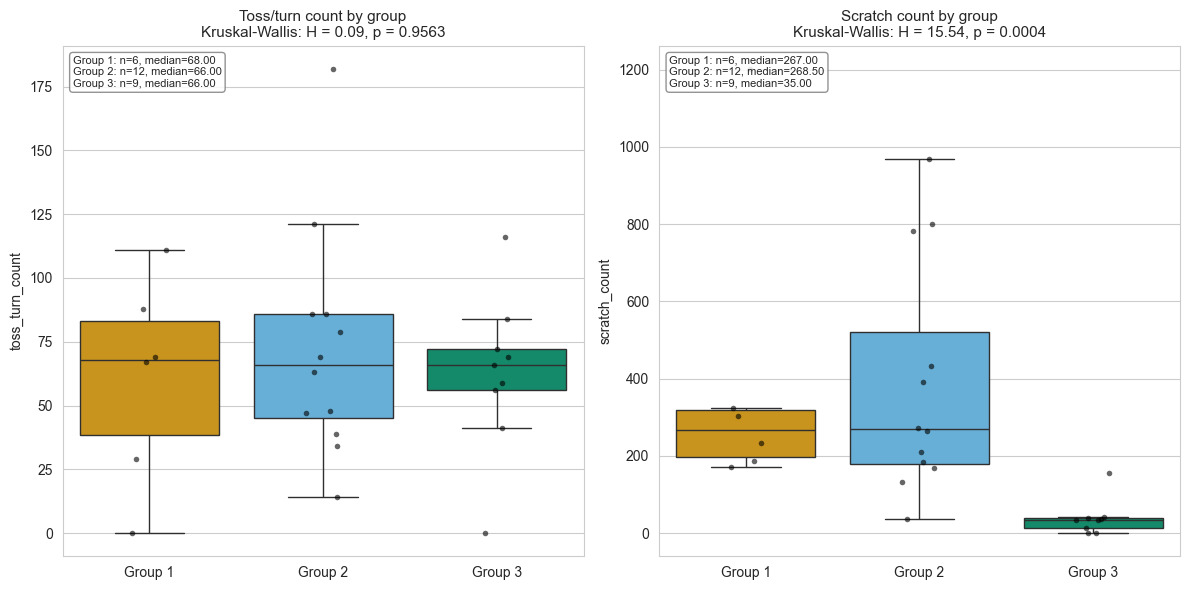

In [123]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
group_boxplot(df, 'toss_turn_count', 'Toss/turn count by group', axs[0])
group_boxplot(df, 'scratch_count', 'Scratch count by group', axs[1])
plt.tight_layout()
plt.show()

## Analysis 2 — Toss/turn and scratch rate per hour of sleep by group

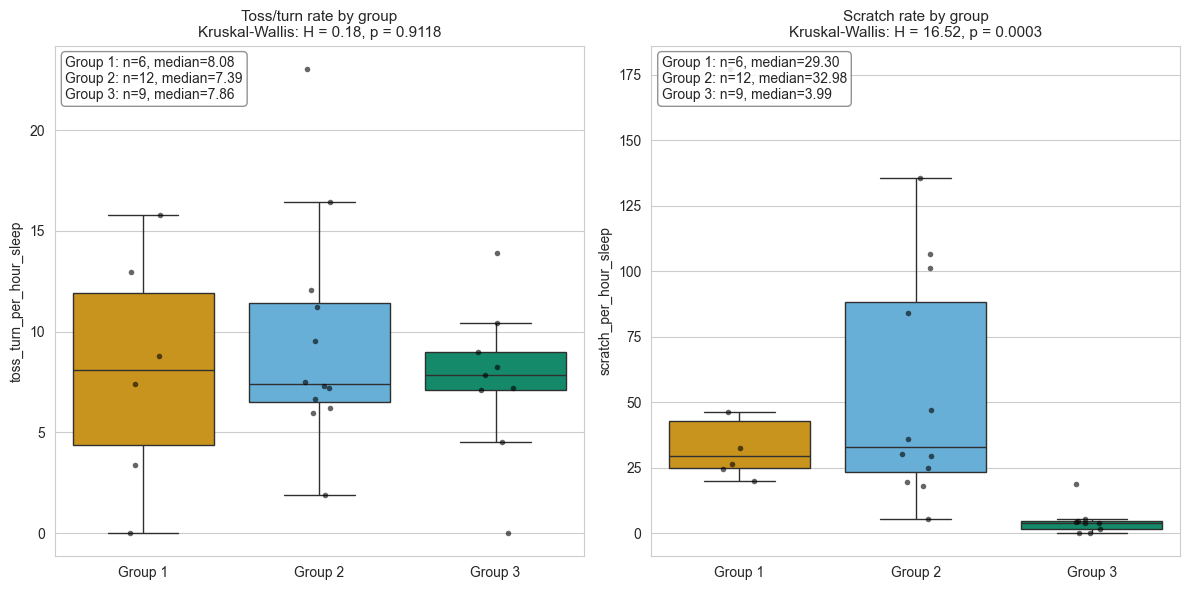

In [134]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
group_boxplot(df, 'toss_turn_per_hour_sleep', 'Toss/turn rate by group', axs[0])
group_boxplot(df, 'scratch_per_hour_sleep', 'Scratch rate by group', axs[1])
plt.tight_layout()
plt.show()

## Post-hoc Scratch analysis? Is it relevant?

## Analysis 3 — True sleep duration by group

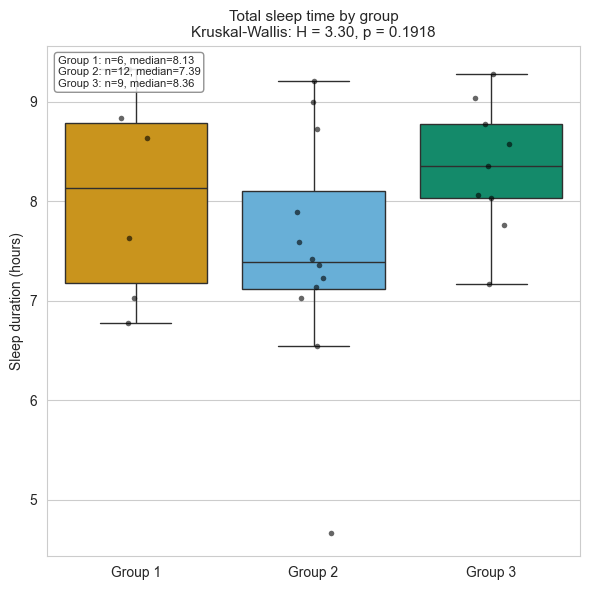

In [113]:
fig, ax = plt.subplots(figsize=(6, 6))
group_boxplot(df, 'true_sleep_hours', 'Total sleep time by group', ax)
ax.set_ylabel('Sleep duration (hours)')
plt.tight_layout()
plt.show()

## Analysis 4 — Correlations: sleep duration, scratch rate, toss/turn rate (all participants)

=== Pooled correlations across ALL participants (n=27) ===

true_sleep_hours vs scratch_per_hour_sleep: rho=-0.336, p=0.0867, n=27
true_sleep_hours vs toss_turn_per_hour_sleep: rho=-0.287, p=0.1466, n=27
scratch_per_hour_sleep vs toss_turn_per_hour_sleep: rho=0.432, p=0.0244, n=27

Pooled and per-group regression, correlation, and p-value are shown directly on the plots below.


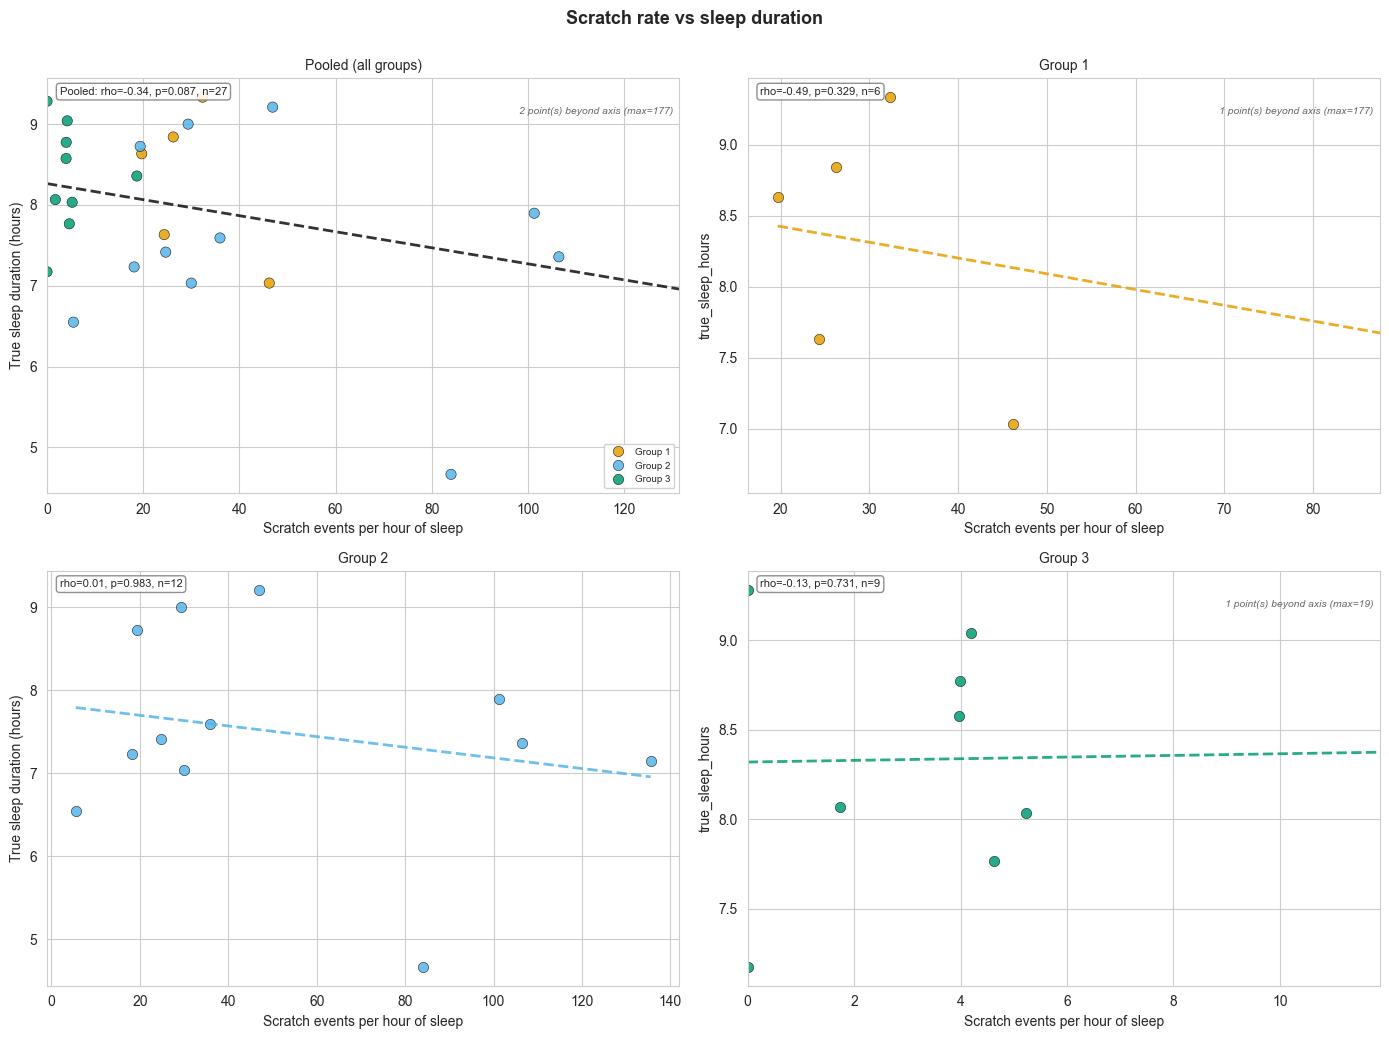

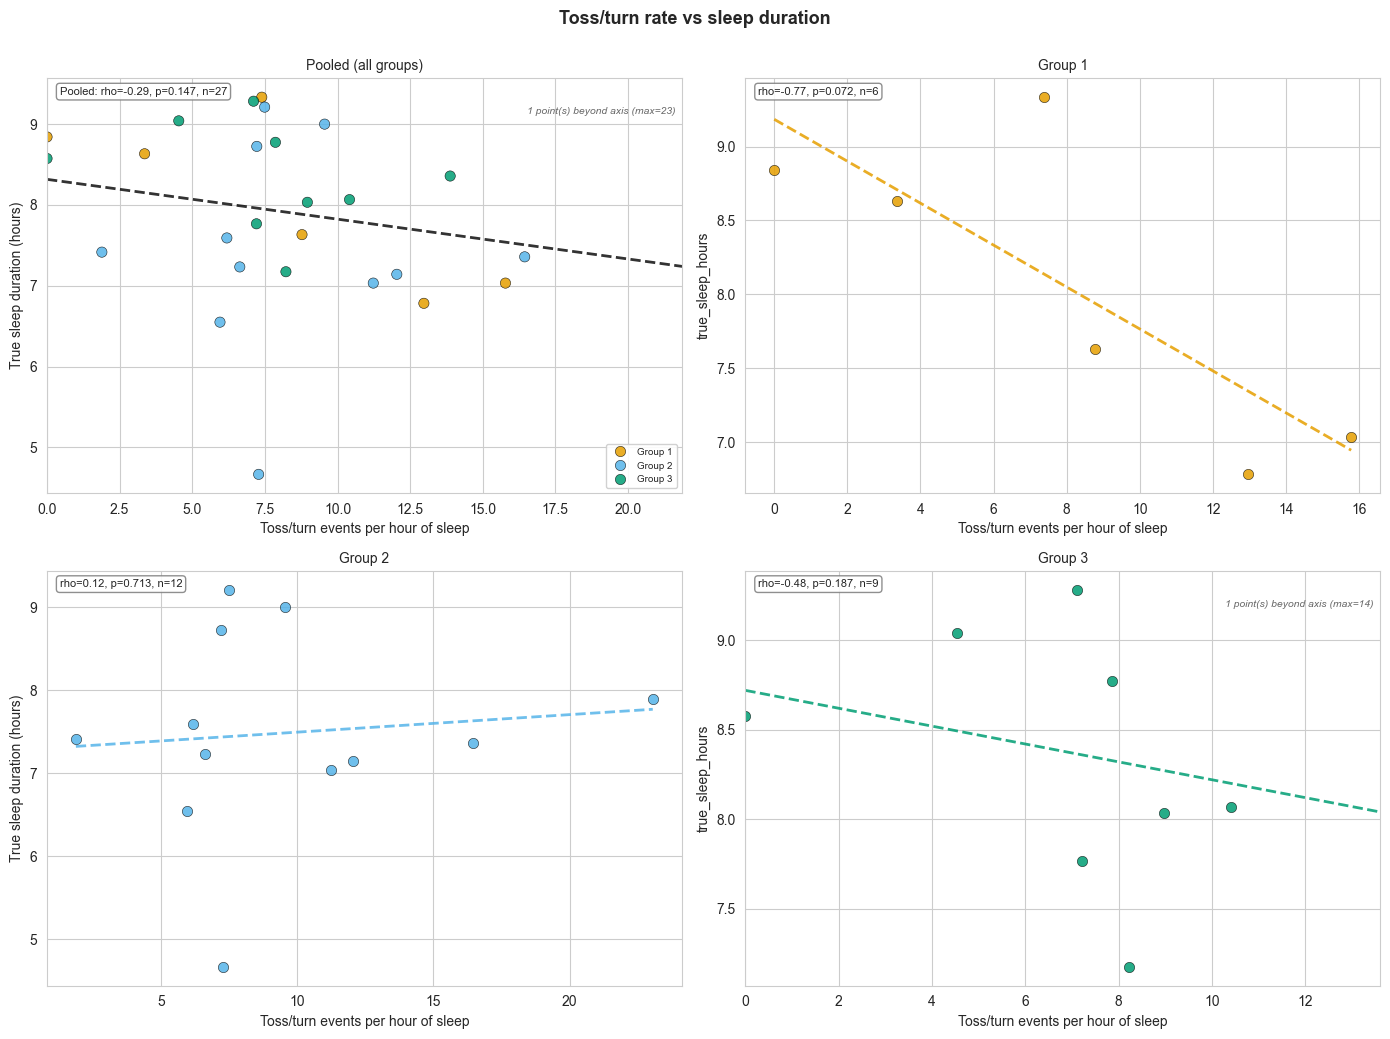

In [114]:
print(f"=== Pooled correlations across ALL participants (n={len(df)}) ===\n")
corr_vars_all = ['true_sleep_hours', 'scratch_per_hour_sleep', 'toss_turn_per_hour_sleep']

for v1, v2 in itertools.combinations(corr_vars_all, 2):
    sub = df[[v1, v2]].dropna()
    if len(sub) < 3:
        print(f"{v1} vs {v2}: insufficient data (n={len(sub)})")
        continue
    rho, p = spearmanr(sub[v1], sub[v2])
    print(f"{v1} vs {v2}: rho={rho:.3f}, p={p:.4f}, n={len(sub)}")

print("\nPooled and per-group regression, correlation, and p-value are shown directly on the plots below.")

# === Scratch rate vs sleep duration: pooled + one panel per group (2x2) ===
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
axes1_flat = axes1.flatten()
pooled_and_per_group_scatter(
    df, x='scratch_per_hour_sleep', y='true_sleep_hours',
    suptitle='Scratch rate vs sleep duration', axes=axes1_flat
)
for ax in axes1_flat:
    ax.set_xlabel('Scratch events per hour of sleep')
axes1_flat[0].set_ylabel('True sleep duration (hours)')
axes1_flat[2].set_ylabel('True sleep duration (hours)')
plt.tight_layout()
plt.show()

# === Toss/turn rate vs sleep duration: pooled + one panel per group (2x2) ===
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
axes2_flat = axes2.flatten()
pooled_and_per_group_scatter(
    df, x='toss_turn_per_hour_sleep', y='true_sleep_hours',
    suptitle='Toss/turn rate vs sleep duration', axes=axes2_flat
)
for ax in axes2_flat:
    ax.set_xlabel('Toss/turn events per hour of sleep')
axes2_flat[0].set_ylabel('True sleep duration (hours)')
axes2_flat[2].set_ylabel('True sleep duration (hours)')
plt.tight_layout()
plt.show()

## Analysis 4 (continued) — EASI correlations (Severe + Moderate only)

=== Correlations with EASI score (Group 1 + Group 2 only, n=18) ===

easi vs true_sleep_hours: rho=0.076, p=0.7632, n=18
easi vs scratch_per_hour_sleep: rho=0.098, p=0.6987, n=18
easi vs toss_turn_per_hour_sleep: rho=0.377, p=0.1234, n=18
true_sleep_hours vs scratch_per_hour_sleep: rho=-0.184, p=0.4654, n=18
true_sleep_hours vs toss_turn_per_hour_sleep: rho=-0.186, p=0.4603, n=18
scratch_per_hour_sleep vs toss_turn_per_hour_sleep: rho=0.703, p=0.0011, n=18


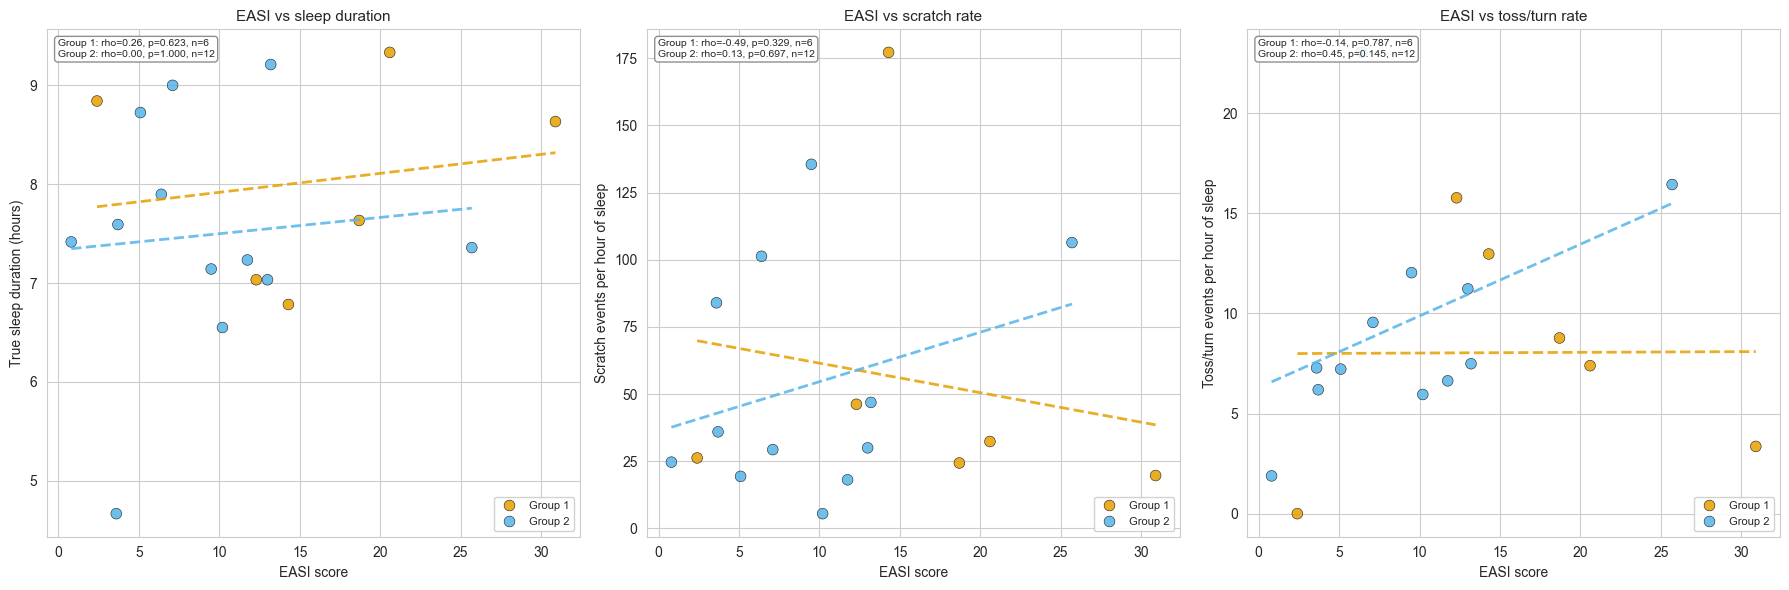

In [98]:
EASI_GROUP_ORDER = ['Group 1', 'Group 2']

eczema_df = df[df['group_label'].isin(EASI_GROUP_ORDER)].copy()
print(f"=== Correlations with EASI score (Group 1 + Group 2 only, n={len(eczema_df)}) ===\n")

corr_vars_easi = ['easi', 'true_sleep_hours', 'scratch_per_hour_sleep', 'toss_turn_per_hour_sleep']
for v1, v2 in itertools.combinations(corr_vars_easi, 2):
    sub = eczema_df[[v1, v2]].dropna()
    if len(sub) < 3:
        print(f"{v1} vs {v2}: insufficient data (n={len(sub)})")
        continue
    rho, p = spearmanr(sub[v1], sub[v2])
    print(f"{v1} vs {v2}: rho={rho:.3f}, p={p:.4f}, n={len(sub)}")

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

scatter_with_group_regression(
    eczema_df, x='easi', y='true_sleep_hours',
    title='EASI vs sleep duration', ax=axs[0], order=EASI_GROUP_ORDER
)
axs[0].set_xlabel('EASI score')
axs[0].set_ylabel('True sleep duration (hours)')

scatter_with_group_regression(
    eczema_df, x='easi', y='scratch_per_hour_sleep',
    title='EASI vs scratch rate', ax=axs[1], order=EASI_GROUP_ORDER
)
axs[1].set_xlabel('EASI score')
axs[1].set_ylabel('Scratch events per hour of sleep')

scatter_with_group_regression(
    eczema_df, x='easi', y='toss_turn_per_hour_sleep',
    title='EASI vs toss/turn rate', ax=axs[2], order=EASI_GROUP_ORDER
)
axs[2].set_xlabel('EASI score')
axs[2].set_ylabel('Toss/turn events per hour of sleep')

plt.tight_layout()
plt.show()

## Analysis 5 — Toss/turn and scratch rate by sleep stage and group

Stage rates computed for all 27 participants.
Total rows: 135


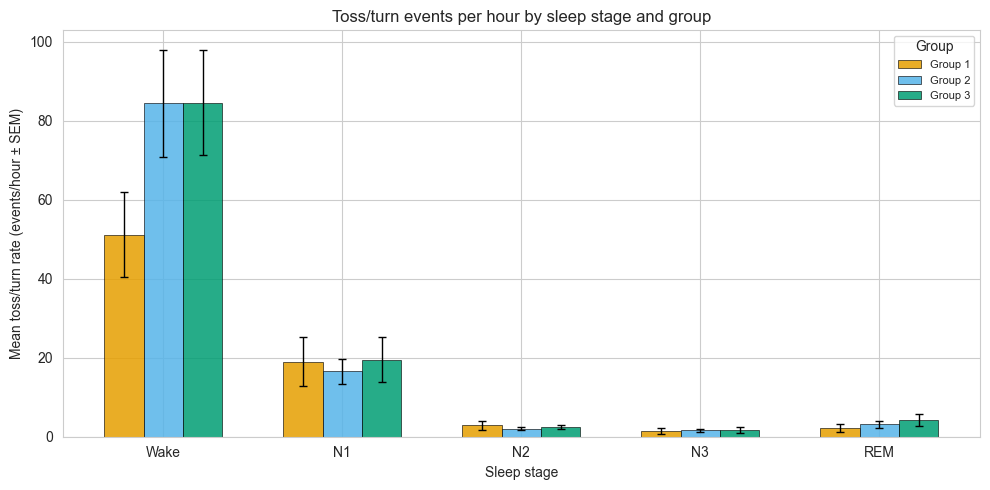

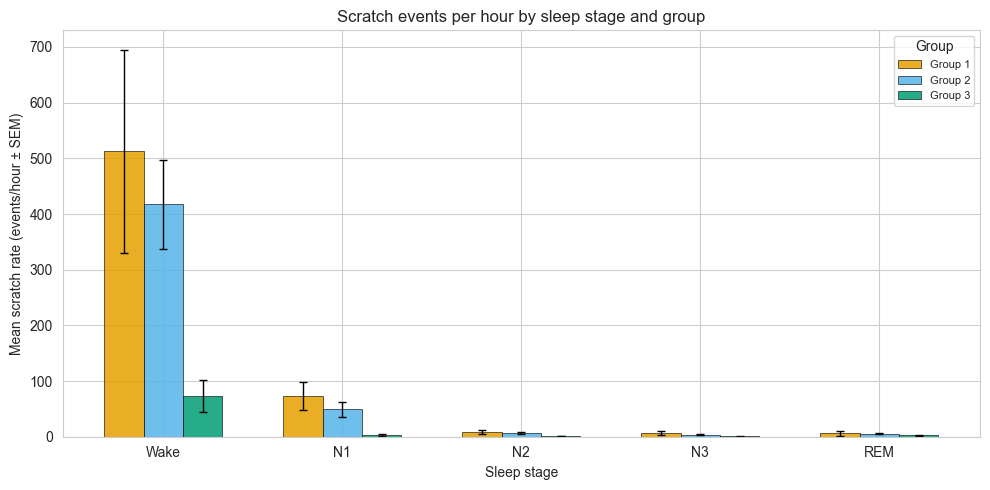

In [99]:
# === Analysis 5: events per hour spent in each sleep stage, by group ===

STAGE_ORDER = ['wake', 'n1', 'n2', 'n3', 'rem']
STAGE_LABELS = {'wake': 'Wake', 'n1': 'N1', 'n2': 'N2', 'n3': 'N3', 'rem': 'REM'}

def compute_stage_rates(row_id, processed_dir):
    """
    For each sleep stage, compute:
      - hours spent in that stage
      - toss/turn events per hour in that stage
      - scratch events per hour in that stage
    Returns a dict keyed by stage, or None if file unavailable.
    """
    visit_dir = resolve_processed_path(row_id, processed_dir)
    if visit_dir is None:
        return None

    tt_files = list(visit_dir.glob("*_acti_psg_SSandArousal_1s_tt.csv"))
    if not tt_files:
        return None

    tt_df = pd.read_csv(tt_files[0])
    if 'Sleep.stage' not in tt_df.columns:
        return None

    tt_df['stage_lower'] = tt_df['Sleep.stage'].str.strip().str.lower()
    tt_df['tossnturn'] = pd.to_numeric(tt_df['tossnturn'], errors='coerce').fillna(0)
    tt_df['Scratch'] = pd.to_numeric(tt_df['Scratch'], errors='coerce').fillna(0)

    results = {}
    for stage in STAGE_ORDER:
        stage_mask = tt_df['stage_lower'] == stage
        stage_seconds = stage_mask.sum()
        stage_hours = stage_seconds / 3600

        if stage_hours > 0:
            tt_rate = tt_df.loc[stage_mask, 'tossnturn'].sum() / stage_hours
            scratch_rate = tt_df.loc[stage_mask, 'Scratch'].sum() / stage_hours
        else:
            tt_rate = np.nan
            scratch_rate = np.nan

        results[stage] = {
            'hours': stage_hours,
            'toss_turn_per_hour': tt_rate,
            'scratch_per_hour': scratch_rate
        }
    return results


# === Build per-participant stage rate dataframe ===
stage_rows = []
failed_stage = []

for _, row in df.iterrows():
    rates = compute_stage_rates(row['participant_id'], processed_dir)
    if rates is None:
        failed_stage.append(row['participant_id'])
        continue
    for stage in STAGE_ORDER:
        stage_rows.append({
            'participant_id': row['participant_id'],
            'group_label': row['group_label'],
            'stage': stage,
            'toss_turn_per_hour': rates[stage]['toss_turn_per_hour'],
            'scratch_per_hour': rates[stage]['scratch_per_hour'],
            'hours_in_stage': rates[stage]['hours']
        })

stage_df = pd.DataFrame(stage_rows)

if failed_stage:
    print(f"Could not compute stage rates for: {failed_stage}")
else:
    print(f"Stage rates computed for all {len(df)} participants.")
print(f"Total rows: {len(stage_df)}")


# === Compute group mean and SEM per stage ===
def group_stage_stats(stage_df, value_col):
    """Returns mean and SEM per group per stage, excluding NaN (stage not present)."""
    return stage_df.groupby(['group_label', 'stage'])[value_col].agg(
        mean='mean', sem=lambda x: x.sem(ddof=1)
    ).reset_index()


tt_stats = group_stage_stats(stage_df, 'toss_turn_per_hour')
scratch_stats = group_stage_stats(stage_df, 'scratch_per_hour')


# === Plotting function ===
def plot_stage_grouped_bar(stats_df, value_label, title, ax,
                            order=GROUP_ORDER, palette=GROUP_PALETTE,
                            stage_order=STAGE_ORDER, stage_labels=STAGE_LABELS):
    """Grouped bar chart: x = sleep stage, grouped bars = groups, y = mean events/hour."""
    x = np.arange(len(stage_order))
    n_groups = len(order)
    bar_width = 0.22
    offsets = np.linspace(-(n_groups - 1) / 2, (n_groups - 1) / 2, n_groups) * bar_width

    for offset, group in zip(offsets, order):
        sub = stats_df[stats_df['group_label'] == group].set_index('stage')
        means = [sub.loc[s, 'mean'] if s in sub.index else np.nan for s in stage_order]
        sems = [sub.loc[s, 'sem'] if s in sub.index else 0 for s in stage_order]

        ax.bar(x + offset, means, width=bar_width, label=group,
               color=palette[group], alpha=0.85, edgecolor='black', linewidth=0.5)
        ax.errorbar(x + offset, means, yerr=sems, fmt='none',
                    color='black', capsize=3, linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels([stage_labels[s] for s in stage_order])
    ax.set_xlabel('Sleep stage')
    ax.set_ylabel(f'Mean {value_label} (events/hour ± SEM)')
    ax.set_title(title)
    ax.legend(title='Group', fontsize=8)


# === Figure 1: Toss/turn rate by sleep stage and group ===
fig1, ax1 = plt.subplots(figsize=(10, 5))
plot_stage_grouped_bar(
    tt_stats,
    value_label='toss/turn rate',
    title='Toss/turn events per hour by sleep stage and group',
    ax=ax1
)
plt.tight_layout()
plt.show()

# === Figure 2: Scratch rate by sleep stage and group ===
fig2, ax2 = plt.subplots(figsize=(10, 5))
plot_stage_grouped_bar(
    scratch_stats,
    value_label='scratch rate',
    title='Scratch events per hour by sleep stage and group',
    ax=ax2
)
plt.tight_layout()
plt.show()

# MERGING GROUP 1 AND GROUP 2 into ONE ECZEMA GROUP

In [124]:
# === Merge Group 1 (systemic therapy) and Group 2 (no systemic therapy) into one Eczema group ===
from scipy.stats import mannwhitneyu

MERGED_GROUP_PALETTE = {
    'Eczema': '#E69F00',   # orange — reused from Group 1's colour
    'Control': '#009E73',  # bluish green — unchanged from Group 3
}
MERGED_GROUP_ORDER = ['Eczema', 'Control']

MERGED_LABELS = {'Group 1': 'Eczema', 'Group 2': 'Eczema', 'Group 3': 'Control'}

df_merged = df.copy()
df_merged['group_label'] = df_merged['group_label'].map(MERGED_LABELS)

print(df_merged['group_label'].value_counts(dropna=False))

group_label
Eczema     18
Control     9
Name: count, dtype: int64


## Helper functions

In [136]:
def group_boxplot_mw(data, value_col, title, ax, order=MERGED_GROUP_ORDER, palette=MERGED_GROUP_PALETTE):
    """Same as group_boxplot, but reports Mann-Whitney U instead of Kruskal-Wallis —
    the correct test for exactly two groups."""
    sns.boxplot(data=data, x='group_label', y=value_col, order=order, hue='group_label',
                palette=palette, legend=False, ax=ax, showfliers=False)
    sns.stripplot(data=data, x='group_label', y=value_col, order=order, ax=ax,
                  color='black', alpha=0.6, jitter=True, size=4)

    groups = [data[data['group_label'] == g][value_col].dropna().values for g in order]

    if len(groups) == 2 and all(len(g) > 0 for g in groups):
        stat, p = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        p_str = f"p = {p:.4f}" if p >= 0.0001 else "p < 0.0001"
        subtitle = f"Mann-Whitney U: U = {stat:.1f}, {p_str}"
    else:
        stat, p = None, None
        subtitle = "Mann-Whitney U: insufficient data"

    stats_lines = []
    for g, vals in zip(order, groups):
        if len(vals) > 0:
            stats_lines.append(f"{g}: n={len(vals)}, median={np.median(vals):.2f}")
        else:
            stats_lines.append(f"{g}: n=0")
    stats_text = "\n".join(stats_lines)

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, va='top', ha='left',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

    ax.set_title(f"{title}\n{subtitle}", fontsize=11)
    ax.set_xlabel('')
    return stat, p

## Toss/turn counts and scratch counts between groups

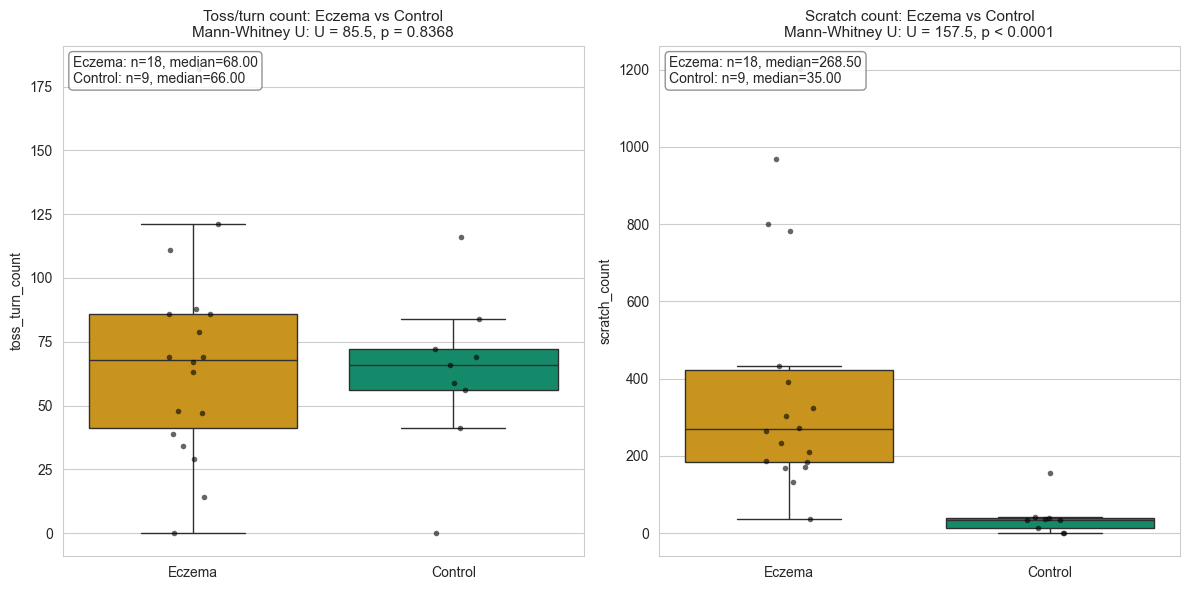

In [137]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
group_boxplot_mw(df_merged, 'toss_turn_count', 'Toss/turn count: Eczema vs Control', axs[0])
group_boxplot_mw(df_merged, 'scratch_count', 'Scratch count: Eczema vs Control', axs[1])
plt.tight_layout()
plt.show()

## Tossnturn and scratch rates between groups

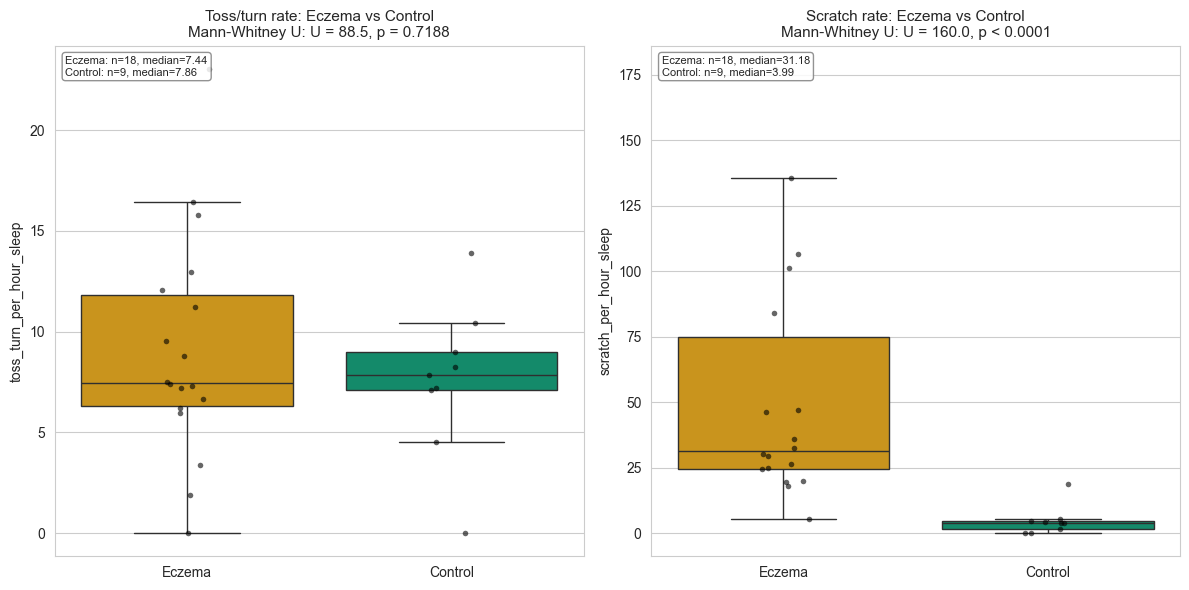

In [127]:
# === Compare toss/turn and scratch rates between Eczema and Control (plot) ===
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
group_boxplot_mw(df_merged, 'toss_turn_per_hour_sleep', 'Toss/turn rate: Eczema vs Control', axs[0])
group_boxplot_mw(df_merged, 'scratch_per_hour_sleep', 'Scratch rate: Eczema vs Control', axs[1])
plt.tight_layout()
plt.show()

## Total sleep time between groups

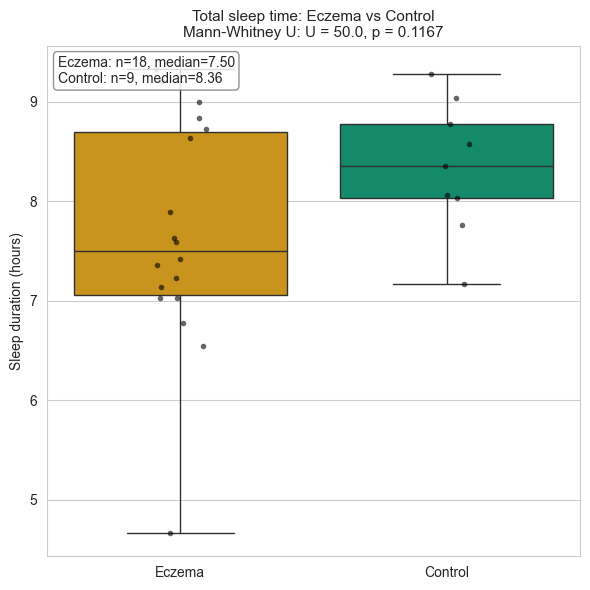

In [138]:
fig, ax = plt.subplots(figsize=(6, 6))
group_boxplot_mw(df_merged, 'true_sleep_hours', 'Total sleep time: Eczema vs Control', ax)
ax.set_ylabel('Sleep duration (hours)')
plt.tight_layout()
plt.show()

## Rates vs duration

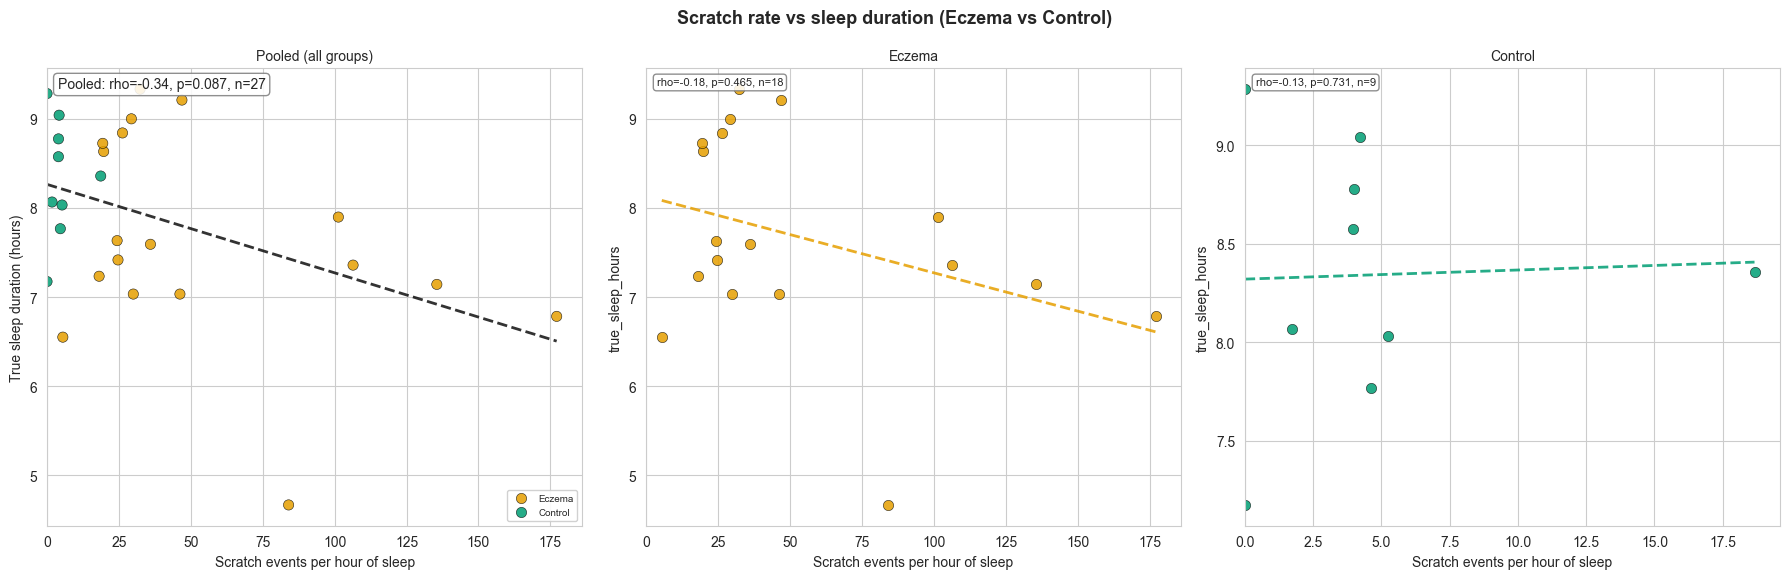

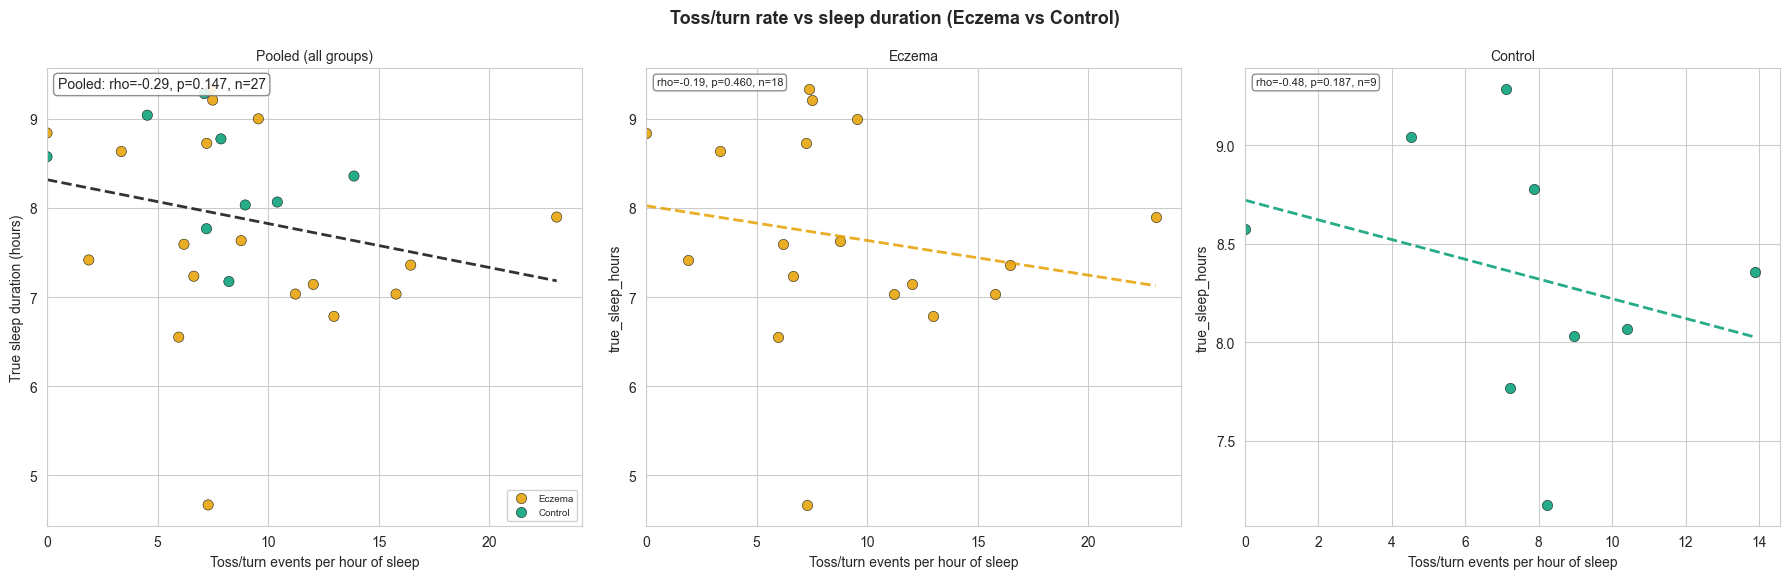

In [139]:
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5.5))
pooled_and_per_group_scatter(
    df_merged, x='scratch_per_hour_sleep', y='true_sleep_hours',
    suptitle='Scratch rate vs sleep duration (Eczema vs Control)',
    axes=axes1, order=MERGED_GROUP_ORDER, palette=MERGED_GROUP_PALETTE
)
for ax in axes1:
    ax.set_xlabel('Scratch events per hour of sleep')
axes1[0].set_ylabel('True sleep duration (hours)')
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5.5))
pooled_and_per_group_scatter(
    df_merged, x='toss_turn_per_hour_sleep', y='true_sleep_hours',
    suptitle='Toss/turn rate vs sleep duration (Eczema vs Control)',
    axes=axes2, order=MERGED_GROUP_ORDER, palette=MERGED_GROUP_PALETTE
)
for ax in axes2:
    ax.set_xlabel('Toss/turn events per hour of sleep')
axes2[0].set_ylabel('True sleep duration (hours)')
plt.tight_layout()
plt.show()

## EASI correlations

=== Correlations with EASI score (Eczema group only, n=18) ===

easi vs true_sleep_hours: rho=0.076, p=0.7632, n=18
easi vs scratch_per_hour_sleep: rho=0.098, p=0.6987, n=18
easi vs toss_turn_per_hour_sleep: rho=0.377, p=0.1234, n=18
true_sleep_hours vs scratch_per_hour_sleep: rho=-0.184, p=0.4654, n=18
true_sleep_hours vs toss_turn_per_hour_sleep: rho=-0.186, p=0.4603, n=18
scratch_per_hour_sleep vs toss_turn_per_hour_sleep: rho=0.703, p=0.0011, n=18


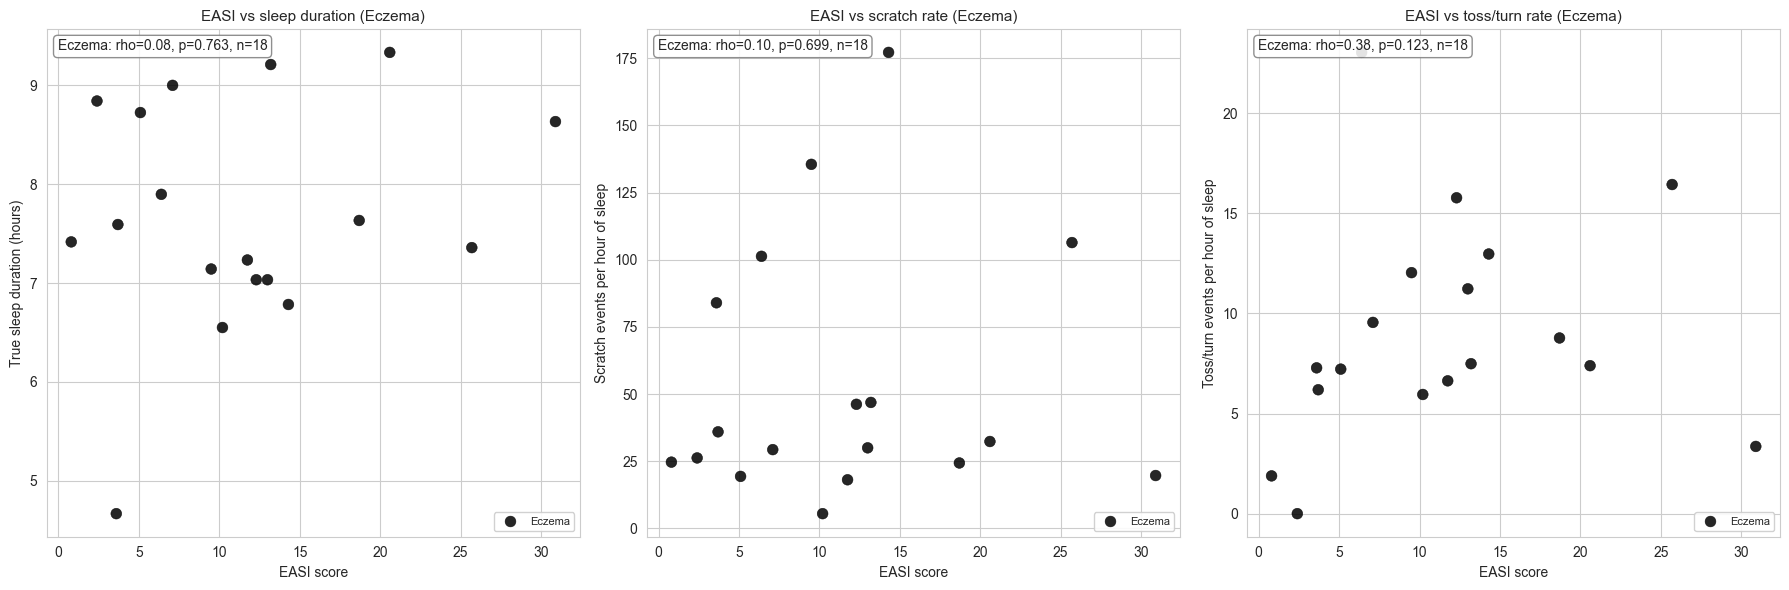

In [140]:
eczema_df = df_merged[df_merged['group_label'] == 'Eczema'].copy()
print(f"=== Correlations with EASI score (Eczema group only, n={len(eczema_df)}) ===\n")

corr_vars_easi = ['easi', 'true_sleep_hours', 'scratch_per_hour_sleep', 'toss_turn_per_hour_sleep']
for v1, v2 in itertools.combinations(corr_vars_easi, 2):
    sub = eczema_df[[v1, v2]].dropna()
    if len(sub) < 3:
        print(f"{v1} vs {v2}: insufficient data (n={len(sub)})")
        continue
    rho, p = spearmanr(sub[v1], sub[v2])
    print(f"{v1} vs {v2}: rho={rho:.3f}, p={p:.4f}, n={len(sub)}")

# Single-group plot — override the palette to black/white here only,
# since there's no second group left to distinguish it from.
BW_PALETTE = {'Eczema': 'black'}

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

scatter_with_group_regression(eczema_df, x='easi', y='true_sleep_hours',
    title='EASI vs sleep duration (Eczema)', ax=axs[0], order=['Eczema'], palette=BW_PALETTE,
    show_line=False)
axs[0].set_xlabel('EASI score'); axs[0].set_ylabel('True sleep duration (hours)')

scatter_with_group_regression(eczema_df, x='easi', y='scratch_per_hour_sleep',
    title='EASI vs scratch rate (Eczema)', ax=axs[1], order=['Eczema'], palette=BW_PALETTE,
    show_line=False)
axs[1].set_xlabel('EASI score'); axs[1].set_ylabel('Scratch events per hour of sleep')

scatter_with_group_regression(eczema_df, x='easi', y='toss_turn_per_hour_sleep',
    title='EASI vs toss/turn rate (Eczema)', ax=axs[2], order=['Eczema'], palette=BW_PALETTE,
    show_line=False)
axs[2].set_xlabel('EASI score'); axs[2].set_ylabel('Toss/turn events per hour of sleep')

plt.tight_layout()
plt.show()

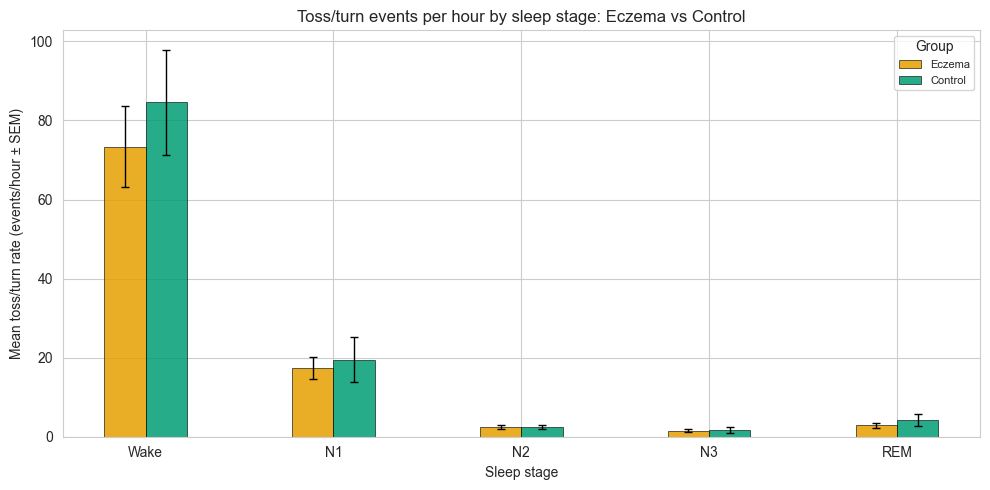

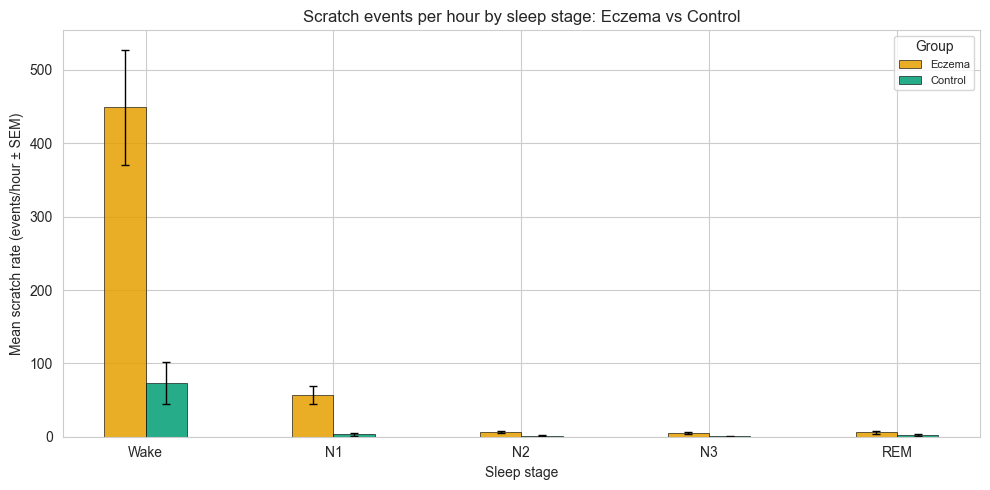

In [107]:
stage_rows_merged = []
failed_stage_merged = []

for _, row in df_merged.iterrows():
    rates = compute_stage_rates(row['participant_id'], processed_dir)
    if rates is None:
        failed_stage_merged.append(row['participant_id'])
        continue
    for stage in STAGE_ORDER:
        stage_rows_merged.append({
            'participant_id': row['participant_id'],
            'group_label': row['group_label'],
            'stage': stage,
            'toss_turn_per_hour': rates[stage]['toss_turn_per_hour'],
            'scratch_per_hour': rates[stage]['scratch_per_hour'],
            'hours_in_stage': rates[stage]['hours']
        })

stage_df_merged = pd.DataFrame(stage_rows_merged)
if failed_stage_merged:
    print(f"Could not compute stage rates for: {failed_stage_merged}")

tt_stats_merged = group_stage_stats(stage_df_merged, 'toss_turn_per_hour')
scratch_stats_merged = group_stage_stats(stage_df_merged, 'scratch_per_hour')

fig1, ax1 = plt.subplots(figsize=(10, 5))
plot_stage_grouped_bar(tt_stats_merged, value_label='toss/turn rate',
    title='Toss/turn events per hour by sleep stage: Eczema vs Control',
    ax=ax1, order=MERGED_GROUP_ORDER, palette=MERGED_GROUP_PALETTE)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 5))
plot_stage_grouped_bar(scratch_stats_merged, value_label='scratch rate',
    title='Scratch events per hour by sleep stage: Eczema vs Control',
    ax=ax2, order=MERGED_GROUP_ORDER, palette=MERGED_GROUP_PALETTE)
plt.tight_layout()
plt.show()

# Comorbidity analysis

In [108]:
print(df.columns.tolist())

['participant_id', 'group', 'easi', 'has_edf', 'has_csv', 'has_zip', 'has_summary_csvs', 'has_night0_edf', 'has_akti', 'has_ssarousal', 'has_ssarousal_tt', 'eligible_for_sync', 'Asthma', 'Hayfever', 'Food allergies', 'Contact allergies', 'comorbidity_count', 'lag_seconds', 'lag_warning', 'toss_turn_count', 'scratch_count', 'recording_duration_hours', 'toss_turn_per_hour', 'scratch_per_hour', 'sync_correlation_psg', 'sync_correlation_pvalue', 'sync_status', 'error_reason', 'group_label', 'true_sleep_hours', 'toss_turn_per_hour_sleep', 'scratch_per_hour_sleep']


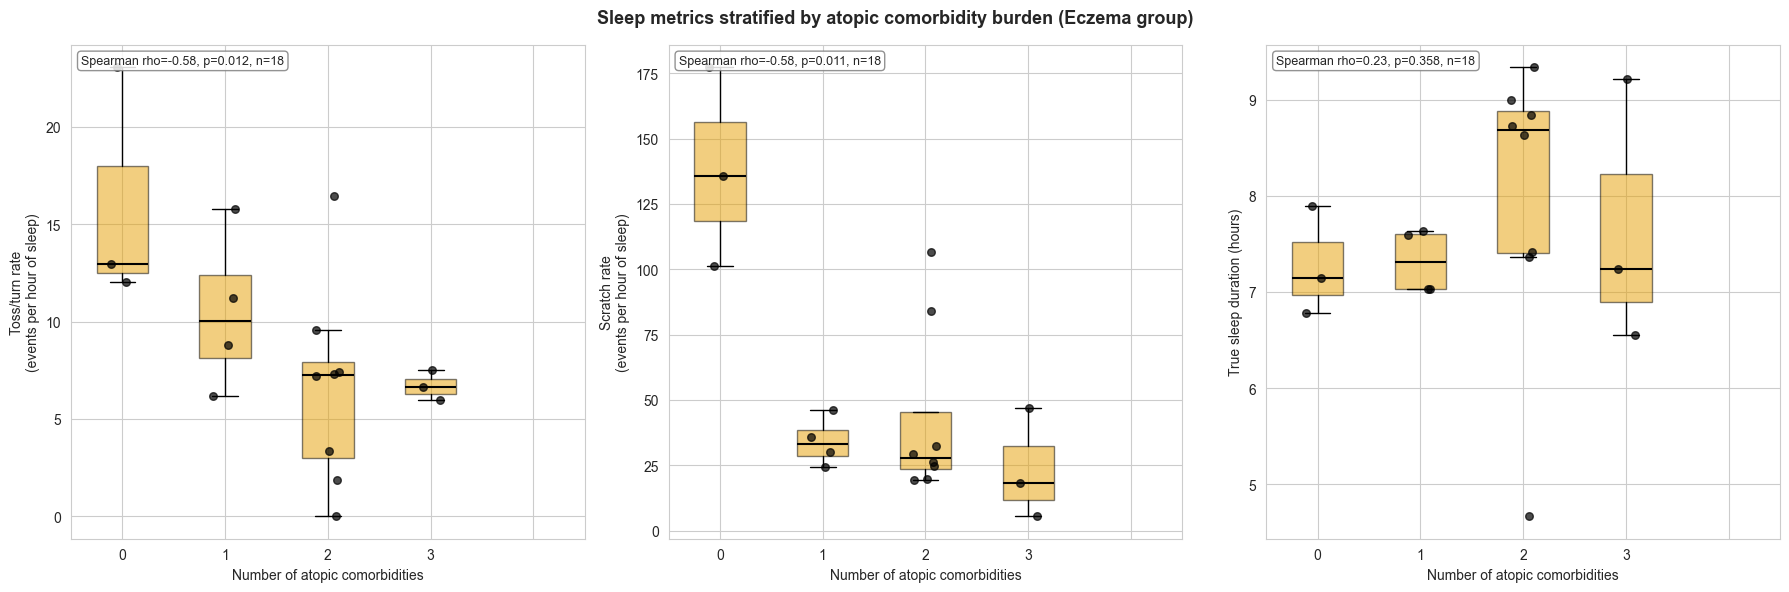

In [109]:
# === Toss/turn, scratch & sleep duration stratified by comorbidity count (Eczema only) ===
plot_df = df_merged[df_merged['group_label'] == 'Eczema'].copy()

metrics = [
    ('toss_turn_per_hour_sleep', 'Toss/turn rate\n(events per hour of sleep)'),
    ('scratch_per_hour_sleep',   'Scratch rate\n(events per hour of sleep)'),
    ('true_sleep_hours',         'True sleep duration (hours)'),
]

count_levels = [0, 1, 2, 3, 4]

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, ylabel) in zip(axs, metrics):
    sub = plot_df[['comorbidity_count', col]].dropna()

    # Boxplot per count level (only levels that have data), points overlaid
    present_levels = [lvl for lvl in count_levels if (sub['comorbidity_count'] == lvl).any()]
    data_by_level = [sub[sub['comorbidity_count'] == lvl][col].values for lvl in present_levels]

    ax.boxplot(data_by_level, positions=present_levels, widths=0.5,
               showfliers=False, patch_artist=True,
               boxprops=dict(facecolor='#E69F00', alpha=0.5, edgecolor='black'),
               medianprops=dict(color='black', linewidth=1.5))

    # Jittered raw points
    rng = np.random.default_rng(0)
    for lvl in present_levels:
        vals = sub[sub['comorbidity_count'] == lvl][col].values
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(np.full(len(vals), lvl) + jitter, vals,
                   color='black', alpha=0.7, s=30, zorder=3)

    # Spearman correlation of metric vs comorbidity count (treats count as ordinal)
    if sub['comorbidity_count'].nunique() > 1 and len(sub) >= 3:
        rho, p = spearmanr(sub['comorbidity_count'], sub[col])
        p_str = f"p={p:.3f}" if p >= 0.001 else "p<0.001"
        ax.text(0.02, 0.98, f"Spearman rho={rho:.2f}, {p_str}, n={len(sub)}",
                transform=ax.transAxes, va='top', ha='left', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

    ax.set_xlabel('Number of atopic comorbidities')
    ax.set_ylabel(ylabel)
    ax.set_xticks(count_levels)
    ax.set_xlim(-0.5, 4.5)

fig.suptitle('Sleep metrics stratified by atopic comorbidity burden (Eczema group)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Notes

- **Sample size**: per-group N is small — Kruskal-Wallis (non-parametric) was used throughout rather than ANOVA, and exact group sizes are printed alongside every test for transparency.
- **Sleep duration** is defined as total time scored as any stage other than `Wake` (REM/NREM not distinguished). Revisit if a different definition is more appropriate for the dissertation.
- **EASI correlations** are restricted to Severe + Moderate participants, since EASI is not a meaningful score for the Control group.
- **Zero vs missing toss/turn data**: a zero count is treated as a genuine observation (no toss/turn events detected) and retained in all analyses. Missing (NaN) values are excluded pairwise by each test/plot, not imputed.
- All correlations use **Spearman's rho** rather than Pearson, given the small sample size and no assumption of linear/normal relationships.